<a href="https://colab.research.google.com/github/Dicta262/AnalystLab-Africa-Internship-Program/blob/main/Apple_Stock_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install yfinance

In [ ]:
import yfinance as yf

In [ ]:
# Download Apple stock data
df = yf.download("AAPL",
                 start="2021-06-09",
                 end="2026-06-09")

/tmp/ipykernel_1995/3451867373.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("AAPL",
[*********************100%***********************]  1 of 1 completed


In [ ]:
# Save to CSV
df.to_csv("AAPL.csv")

In [ ]:
print (df.head())

Price            Close        High         Low        Open    Volume
Ticker            AAPL        AAPL        AAPL        AAPL      AAPL
Date                                                                
2021-06-09  123.920204  124.524553  123.325605  123.998186  56877900
2021-06-10  122.925964  124.953450  122.760258  123.812985  71186400
2021-06-11  124.134666  124.222398  122.916226  123.335370  53522400
2021-06-14  127.185631  127.244114  123.861731  124.592794  96906500
2021-06-15  126.366844  127.302613  126.123156  126.659273  62746300


In [ ]:
df.to_csv("apple stock.csv")

In [ ]:
import os
print (os.getcwd())

/content


In [ ]:
from google.colab import files
files.download("apple stock.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

df.to_csv("/content/drive/My Drive/apple stock.csv")

Mounted at /content/drive


# Advanced Python for Data Analysis: Apple Stock Market Analysis

## Project Overview
This project applies advanced Python techniques for data transformation, time-series analysis, and feature engineering using historical Apple stock market data.

### Objectives
- Perform data cleaning and preprocessing
- Apply advanced Pandas transformations
- Conduct time-series analysis
- Engineer useful financial features
- Visualize stock market trends
- Generate insights and conclusions


In [ ]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')


# Data Loading

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving apple stock.csv to apple stock.csv


In [ ]:
df = pd.read_csv("apple stock.csv")

df.head()

,Price,Close,High,Low,Open,Volume
0,Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
1,Date,NaN,NaN,NaN,NaN,NaN
2,6/9/2021,123.9202042,124.524553,123.3256049,123.9981861,56877900
3,6/10/2021,122.9259644,124.9534501,122.7602583,123.8129847,71186400
4,6/11/2021,124.1346664,124.222398,122.9162264,123.3353701,53522400


# Data Exploration

In [ ]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
df.info()


Dataset Shape:
(1257, 6)

Column Names:
Index(['Price', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1257 entries, 0 to 1256
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Price   1257 non-null   object
 1   Close   1256 non-null   object
 2   High    1256 non-null   object
 3   Low     1256 non-null   object
 4   Open    1256 non-null   object
 5   Volume  1256 non-null   object
dtypes: object(6)
memory usage: 59.1+ KB


In [ ]:
print("Missing Values")
print(df.isnull().sum())


Missing Values
Price     0
Close     1
High      1
Low       1
Open      1
Volume    1
dtype: int64


# Data Cleaning and Preprocessing

In [ ]:
# Remove first two unnecessary rows

df = df.iloc[2:].copy()

# Rename columns

df.columns = ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']

# Convert Date

df['Date'] = pd.to_datetime(df['Date'])

# Convert numeric columns

numeric_cols = ['Close', 'High', 'Low', 'Open', 'Volume']

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col])

# Reset Index

df.reset_index(drop=True, inplace=True)

df.head()


,Date,Close,High,Low,Open,Volume
0,2021-06-09,123.920204,124.524553,123.325605,123.998186,56877900
1,2021-06-10,122.925964,124.953450,122.760258,123.812985,71186400
2,2021-06-11,124.134666,124.222398,122.916226,123.335370,53522400
3,2021-06-14,127.185631,127.244113,123.861730,124.592794,96906500
4,2021-06-15,126.366844,127.302613,126.123156,126.659273,62746300


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1255 entries, 0 to 1254
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1255 non-null   datetime64[ns]
 1   Close   1255 non-null   float64       
 2   High    1255 non-null   float64       
 3   Low     1255 non-null   float64       
 4   Open    1255 non-null   float64       
 5   Volume  1255 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 59.0 KB


# Data Transformation Using Pandas

In [ ]:
# Sort by Date

df = df.sort_values('Date')

# Create Year and Month

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.month_name()

df.head()


,Date,Close,High,Low,Open,Volume,Year,Month,Month_Name
0,2021-06-09,123.920204,124.524553,123.325605,123.998186,56877900,2021,6,June
1,2021-06-10,122.925964,124.953450,122.760258,123.812985,71186400,2021,6,June
2,2021-06-11,124.134666,124.222398,122.916226,123.335370,53522400,2021,6,June
3,2021-06-14,127.185631,127.244113,123.861730,124.592794,96906500,2021,6,June
4,2021-06-15,126.366844,127.302613,126.123156,126.659273,62746300,2021,6,June


In [ ]:
monthly_summary = df.groupby('Month_Name').agg({
    'Close':'mean',
    'Volume':'mean'
})

monthly_summary


,Close,Volume
Month_Name,,
April,192.277473,6.231624e+07
August,185.589973,5.977645e+07
December,204.646647,6.685023e+07
February,200.559297,6.195273e+07
January,194.999926,6.910676e+07
July,183.133830,6.281248e+07
June,179.450619,7.164845e+07
March,191.802692,6.559169e+07
May,198.798778,6.782954e+07


# Feature Engineering

In [ ]:
# Daily Price Change

df['Daily_Price_Change'] = df['Close'] - df['Open']

# Percentage Change

df['Percentage_Change'] = (
    (df['Close'] - df['Open']) / df['Open']
) * 100

# Moving Averages

df['MA_7'] = df['Close'].rolling(7).mean()

df['MA_30'] = df['Close'].rolling(30).mean()

# Daily Returns

df['Daily_Return'] = df['Close'].pct_change()

# Volatility

df['Volatility_30'] = (
    df['Daily_Return']
    .rolling(30)
    .std()
)

df.head()


,Date,Close,High,Low,Open,Volume,Year,Month,Month_Name,Daily_Price_Change,Percentage_Change,MA_7,MA_30,Daily_Return,Volatility_30
0,2021-06-09,123.920204,124.524553,123.325605,123.998186,56877900,2021,6,June,-0.077982,-0.062890,NaN,NaN,NaN,NaN
1,2021-06-10,122.925964,124.953450,122.760258,123.812985,71186400,2021,6,June,-0.887020,-0.716419,NaN,NaN,-0.008023,NaN
2,2021-06-11,124.134666,124.222398,122.916226,123.335370,53522400,2021,6,June,0.799296,0.648067,NaN,NaN,0.009833,NaN
3,2021-06-14,127.185631,127.244113,123.861730,124.592794,96906500,2021,6,June,2.592836,2.081048,NaN,NaN,0.024578,NaN
4,2021-06-15,126.366844,127.302613,126.123156,126.659273,62746300,2021,6,June,-0.292428,-0.230878,NaN,NaN,-0.006438,NaN


In [ ]:
monthly_returns = (
    df.resample('M', on='Date')['Close']
    .last()
    .pct_change()
    * 100
)

monthly_returns.head()


/tmp/ipykernel_9210/4243075233.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.resample('M', on='Date')['Close']


,Close
Date,
2021-06-30,NaN
2021-07-31,6.498250
2021-08-31,4.248942
2021-09-30,-6.803652
2021-10-31,5.865718


# Time-Series Analysis

In [ ]:
df.set_index('Date', inplace=True)

# Visualizations

## Stock Closing Price Trend

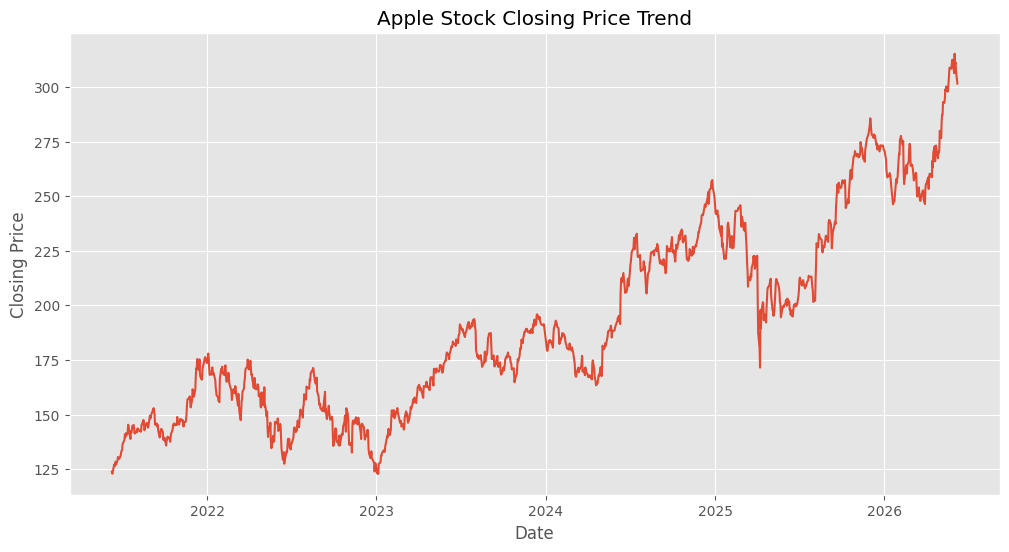

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(df.index, df['Close'])

plt.title('Apple Stock Closing Price Trend')
plt.xlabel('Date')
plt.ylabel('Closing Price')

plt.show()


## Trading Volume Trend

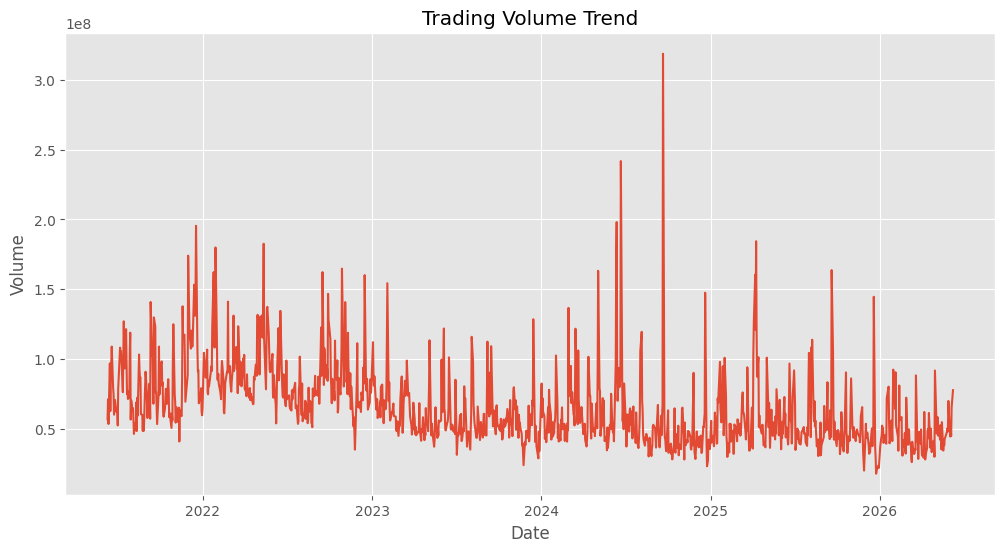

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(df.index, df['Volume'])

plt.title('Trading Volume Trend')
plt.xlabel('Date')
plt.ylabel('Volume')

plt.show()


## Moving Average Analysis

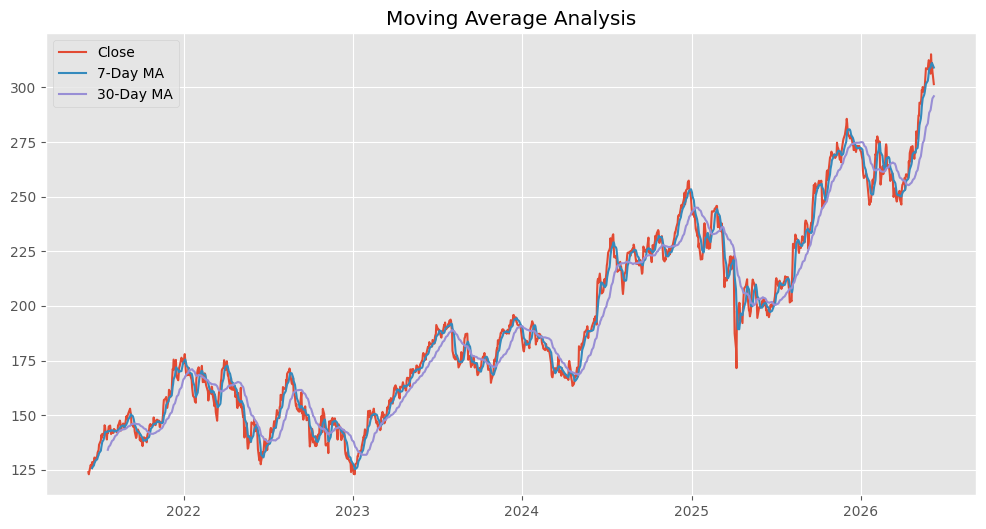

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(df.index, df['Close'], label='Close')

plt.plot(df.index, df['MA_7'], label='7-Day MA')

plt.plot(df.index, df['MA_30'], label='30-Day MA')

plt.legend()

plt.title('Moving Average Analysis')

plt.show()


## Daily Returns Analysis

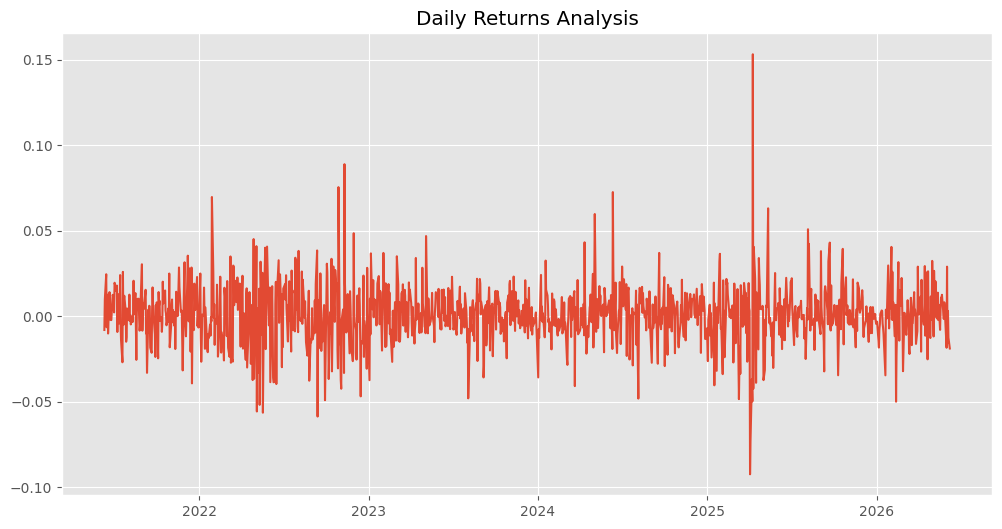

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(df.index, df['Daily_Return'])

plt.title('Daily Returns Analysis')

plt.show()


## Monthly Returns Analysis

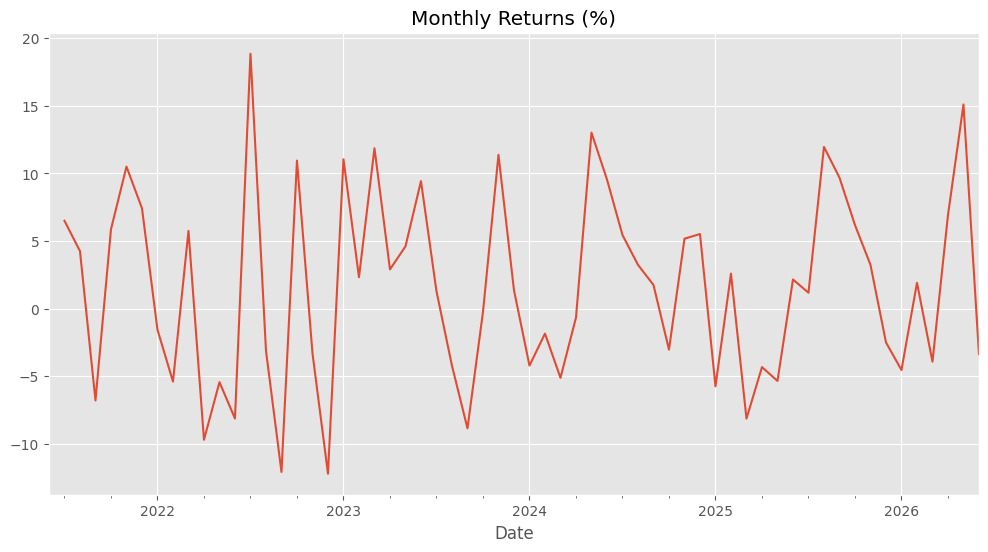

In [ ]:
monthly_returns.plot(figsize=(12,6))

plt.title('Monthly Returns (%)')

plt.show()


## Volatility Analysis

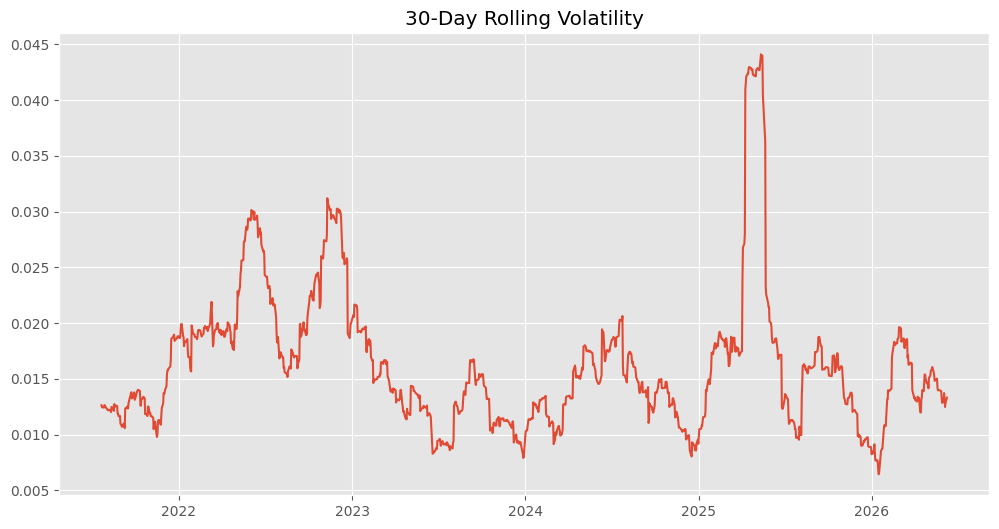

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(df.index, df['Volatility_30'])

plt.title('30-Day Rolling Volatility')

plt.show()


# Summary Statistics

In [ ]:
df.describe()

,Close,High,Low,Open,Volume,Year,Month,Daily_Price_Change,Percentage_Change,MA_7,MA_30,Daily_Return,Volatility_30
count,1255.000000,1255.000000,1255.000000,1255.000000,1.255000e+03,1255.000000,1255.000000,1255.000000,1255.000000,1249.000000,1226.000000,1254.000000,1225.000000
mean,191.716372,193.602675,189.652022,191.512974,6.535321e+07,2023.427888,6.552988,0.203398,0.122508,191.599466,191.117970,0.000858,0.016291
std,44.022089,44.363709,43.694422,44.018307,2.818010e+07,1.499927,3.432910,2.750008,1.474054,43.493067,41.698320,0.017313,0.006275
min,122.925964,124.222398,122.097738,123.335370,1.791060e+07,2021.000000,1.000000,-14.204942,-7.648634,125.252754,131.824980,-0.092456,0.006448
25%,154.339851,156.920463,151.926131,154.870480,4.615660e+07,2022.000000,4.000000,-1.229575,-0.631985,154.765540,156.784986,-0.007589,0.012320
50%,180.775665,182.657836,179.321295,180.674174,5.780870e+07,2023.000000,7.000000,0.198279,0.104011,181.551784,180.758441,0.001137,0.015126
75%,225.504387,227.423449,223.152914,225.535475,7.759175e+07,2025.000000,10.000000,1.638563,0.902877,225.347876,223.301479,0.009627,0.018597
max,315.200012,317.399994,309.649994,314.179993,3.186799e+08,2026.000000,12.000000,26.758623,15.644088,311.202863,295.999419,0.153289,0.044100


# Key Findings

1. Apple's stock price generally exhibited an upward trend over the observed period.

2. Trading volume fluctuated significantly, indicating periods of heightened investor activity.

3. The 7-day moving average captured short-term price movements, while the 30-day moving average highlighted long-term trends.

4. Daily returns revealed regular market fluctuations and occasional sharp movements.

5. Monthly returns showed both positive and negative performance periods.

6. Volatility analysis identified periods of increased market uncertainty and risk.

7. Feature engineering enhanced the analysis by creating additional indicators such as moving averages, returns, and volatility measures.


# Conclusion

This project successfully applied advanced Python techniques to historical Apple stock data. Data cleaning, transformation, time-series analysis, and feature engineering were performed using Pandas and other Python libraries.

The analysis revealed stock price trends, trading volume patterns, returns, and volatility behavior. These insights demonstrate how Python can transform raw financial data into meaningful information for investment analysis and decision-making.
